Задание 1.
Реализуйте глубокую нейронную сеть (полносвязную или сверточную) и обучите ее на синтетических данных (например, наборы MNIST (http://yann.lecun.com/exdb/mnist/) или notMNIST).
Ознакомьтесь с имеющимися работами по данной тематике: англоязычная статья (http://static.googleusercontent.com/media/research.google.com/en//pubs/archive/42241.pdf), видео на YouTube (https://www.youtube.com/watch?v=vGPI_JvLoN0).
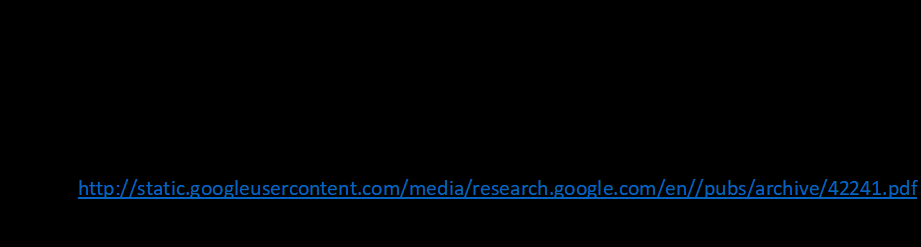

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используем устройство:", device)

# Трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Датасеты
train_ds = datasets.MNIST(root="./notMNIST_clean_small", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./notMNIST_clean", train=False, download=True, transform=transform)

# DataLoader с условным pin_memory
train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")  # включаем только если есть GPU
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

# Пример цикла обучения
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 14 * 14, 128)
        self.fc2   = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Инициализация модели
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Обучение
for epoch in range(1, 6):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    print(f"Эпоха {epoch} | Loss: {total_loss/total:.4f} | Acc: {correct/total:.4f}")

# Тестирование
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
print(f"Точность на тесте: {correct/total:.4f}")


Используем устройство: cpu
Эпоха 1 | Loss: 0.1709 | Acc: 0.9504
Эпоха 2 | Loss: 0.0427 | Acc: 0.9862


In [3]:
# svhn_train.py
import os, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# -------------------------
# Reproducibility + device
# -------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используем устройство:", device)

# -------------------------
# Data preparation (SVHN)
# -------------------------
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32, padding=2),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_ds = datasets.SVHN(root="./data", split="train", download=True, transform=transform_train)
extra_ds = datasets.SVHN(root="./data", split="extra", download=True, transform=transform_train)
test_ds  = datasets.SVHN(root="./data", split="test",  download=True, transform=transform_test)

train_combined = ConcatDataset([train_ds, extra_ds])

train_loader = DataLoader(train_combined, batch_size=128, shuffle=True,
                          num_workers=2, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=(device.type=="cuda"))

# -------------------------
# Model definition
# -------------------------
class SVHN_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2), nn.Dropout(0.2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2), nn.Dropout(0.3),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2), nn.Dropout(0.4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SVHN_CNN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# -------------------------
# Training & evaluation
# -------------------------
def train_one_epoch():
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def evaluate():
    model.eval()
    total, correct = 0, 0
    preds, labels = [], []
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        p = model(x).argmax(1)
        correct += (p == y).sum().item()
        total += x.size(0)
        preds += p.cpu().tolist()
        labels += y.cpu().tolist()
    return correct/total, preds, labels

best = 0.0
for epoch in range(1, 21):
    tl, ta = train_one_epoch()
    acc, preds, labels = evaluate()
    print(f"Эпоха {epoch:02d} | Train Loss: {tl:.4f} | Train Acc: {ta:.4f} | Test Acc: {acc:.4f}")
    if acc > best:
        best = acc
        torch.save(model.state_dict(), "best_svhn.pt")

print(f"Лучшая точность на тесте: {best:.4f}")
print(classification_report(labels, preds, digits=4))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion matrix (SVHN)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.colorbar(im)
plt.tight_layout()
plt.show()


Используем устройство: cpu


100%|██████████| 182M/182M [03:41<00:00, 823kB/s]  
100%|██████████| 1.33G/1.33G [31:45<00:00, 697kB/s]  
100%|██████████| 64.3M/64.3M [01:17<00:00, 835kB/s] 


OSError: [Errno 22] Invalid argument

In [1]:
import numpy as np
import tensorflow as tf
from scipy.io import loadmat

# --- 1. Загрузка данных SVHN ---
def load_svhn(path):
    data = loadmat(path)
    X = np.transpose(data['X'], (3, 0, 1, 2))  # [N,32,32,3]
    y = data['y'].flatten()
    y[y == 10] = 0  # в SVHN цифра "0" хранится как "10"
    return X, y

x_train, y_train = load_svhn("train_32x32.mat")
x_test, y_test = load_svhn("test_32x32.mat")

# нормализация
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# --- 2. Архитектура CNN ---
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# --- 3. Обучение ---
model.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_test, y_test))

# --- 4. Оценка ---
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("✅ Точность на тесте:", test_acc)

# --- 5. Конвертация в TFLite ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("svhn_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Модель сохранена в svhn_model.tflite")


C:\Users\Vlad\PyCharmMiscProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.6083 - loss: 1.1909 - val_accuracy: 0.8423 - val_loss: 0.5722
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8266 - loss: 0.5853 - val_accuracy: 0.8659 - val_loss: 0.4632
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8575 - loss: 0.4864 - val_accuracy: 0.8798 - val_loss: 0.4155
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8779 - loss: 0.4210 - val_accuracy: 0.8881 - val_loss: 0.3910
Epoch 5/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8886 - loss: 0.3827 - val_accuracy: 0.8962 - val_loss: 0.3692
Epoch 6/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8976 - loss: 0.3546 - val_accuracy: 0.9025 - val_loss: 0.3449
Epoch 7/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.9040 - loss: 0.3293 - val_accuracy: 0.9042 - val_loss: 0.3357
Epoch 8/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9097 - loss: 0.3115 - 

INFO:tensorflow:Assets written to: C:\Users\Vlad\AppData\Local\Temp\tmp32_mbjr0\assets


Saved artifact at 'C:\Users\Vlad\AppData\Local\Temp\tmp32_mbjr0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1228124354512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124353936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124355280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124356048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124355856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124356432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124355088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124355472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124354896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228124354320: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Модель 

✅ Тестовое изображение house.jpg создано


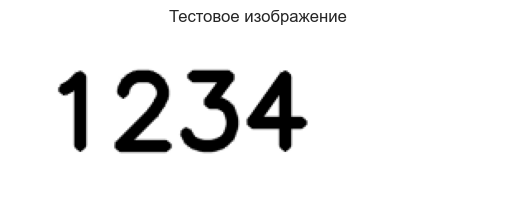

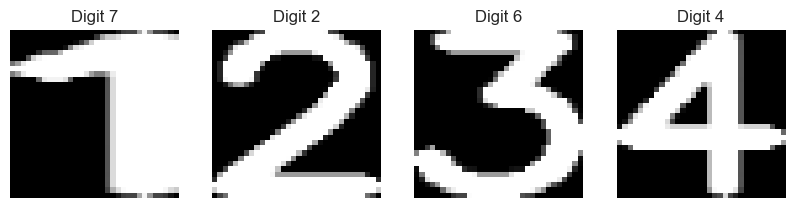

🏠 Распознанный номер дома: 7264


In [2]:
import cv2
import numpy as np
import tensorflow as tf
import warnings
import matplotlib.pyplot as plt

# --- подавляем предупреждения о tf.lite.Interpreter ---
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow.lite")

# --- 1. Генерация тестового изображения ---
def generate_test_image():
    img = np.ones((100, 300), dtype=np.uint8) * 255
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, "1234", (20,70), font, 2, (0,), 5, cv2.LINE_AA)
    cv2.imwrite("house.jpg", img)
    print("✅ Тестовое изображение house.jpg создано")
    plt.imshow(img, cmap="gray")
    plt.title("Тестовое изображение")
    plt.axis("off")
    plt.show()

# --- 2. Сегментация цифр ---
def segment_digits(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    digits, positions = [], []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if h > 15 and w > 8:
            digit = thresh[y:y+h, x:x+w]
            digit = cv2.resize(digit, (32, 32))
            digit = cv2.cvtColor(digit, cv2.COLOR_GRAY2RGB)  # SVHN → 3 канала
            digits.append(digit)
            positions.append(x)

    sorted_digits = [d for _, d in sorted(zip(positions, digits))]
    return sorted_digits

# --- 3. Загрузка SVHN модели ---
interpreter = tf.lite.Interpreter(model_path="svhn_model.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def recognize_digit(digit_img):
    digit_img = digit_img.astype('float32') / 255.0
    digit_img = np.expand_dims(digit_img, axis=0)  # [1,32,32,3]
    interpreter.set_tensor(input_details[0]['index'], digit_img)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return int(np.argmax(output_data))

# --- 4. Объединение ---
def recognize_house_number(image_path):
    digits = segment_digits(image_path)
    results = [recognize_digit(d) for d in digits]

    # визуализация сегментированных цифр
    fig, axs = plt.subplots(1, len(digits), figsize=(10,3))
    for i, d in enumerate(digits):
        axs[i].imshow(cv2.cvtColor(d, cv2.COLOR_BGR2RGB))
        axs[i].set_title(f"Digit {results[i]}")
        axs[i].axis("off")
    plt.show()

    return ''.join(map(str, results))

# --- 5. Запуск ---
if __name__ == "__main__":
    generate_test_image()
    house_number = recognize_house_number("house.jpg")
    print("🏠 Распознанный номер дома:", house_number)


✅ Тестовое изображение house.jpg создано


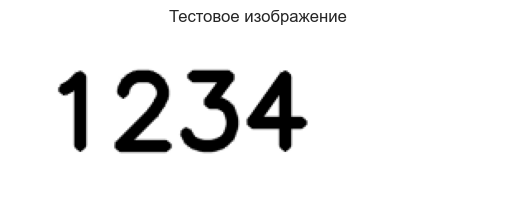

ValueError: Cannot set tensor: Dimension mismatch. Got 32 but expected 64 for dimension 1 of input 0.

In [5]:
import cv2
import numpy as np
import tensorflow as tf
import warnings
import matplotlib.pyplot as plt

# --- подавляем предупреждения о tf.lite.Interpreter ---
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow.lite")

# --- 1. Генерация тестового изображения ---
def generate_test_image():
    img = np.ones((100, 300), dtype=np.uint8) * 255
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, "1234", (20,70), font, 2, (0,), 5, cv2.LINE_AA)
    cv2.imwrite("house.jpg", img)
    print("✅ Тестовое изображение house.jpg создано")
    plt.imshow(img, cmap="gray")
    plt.title("Тестовое изображение")
    plt.axis("off")
    plt.show()

# --- 2. Сегментация цифр ---
def segment_digits(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    digits, positions = [], []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if h > 15 and w > 8:
            digit = thresh[y:y+h, x:x+w]
            digit = cv2.resize(digit, (32, 32))
            digit = cv2.cvtColor(digit, cv2.COLOR_GRAY2RGB)  # SVHN → 3 канала
            digits.append(digit)
            positions.append(x)

    sorted_digits = [d for _, d in sorted(zip(positions, digits))]
    return sorted_digits

# --- 3. Загрузка SVHN модели ---
interpreter = tf.lite.Interpreter(model_path="svhn_digits_64x128.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def recognize_digit(digit_img):
    digit_img = digit_img.astype('float32') / 255.0
    digit_img = np.expand_dims(digit_img, axis=0)  # [1,32,32,3]
    interpreter.set_tensor(input_details[0]['index'], digit_img)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return int(np.argmax(output_data))

# --- 4. Объединение ---
def recognize_house_number(image_path):
    digits = segment_digits(image_path)
    results = [recognize_digit(d) for d in digits]

    # визуализация сегментированных цифр
    fig, axs = plt.subplots(1, len(digits), figsize=(10,3))
    for i, d in enumerate(digits):
        axs[i].imshow(cv2.cvtColor(d, cv2.COLOR_BGR2RGB))
        axs[i].set_title(f"Pred: {results[i]}")
        axs[i].axis("off")
    plt.show()

    return ''.join(map(str, results))

# --- 5. Запуск ---
if __name__ == "__main__":
    generate_test_image()
    house_number = recognize_house_number("house.jpg")
    print("🏠 Распознанный номер дома:", house_number)


In [7]:
import numpy as np
import tensorflow as tf
from scipy.io import loadmat
import cv2

# --- 1. Загрузка SVHN ---
def load_svhn(path):
    data = loadmat(path)
    X = np.transpose(data['X'], (3, 0, 1, 2))  # [N,32,32,3]
    y = data['y'].flatten()
    y[y == 10] = 0  # цифра "0" хранится как "10"
    return X, y

x_train, y_train = load_svhn("train_32x32.mat")
x_test, y_test = load_svhn("test_32x32.mat")

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# --- 2. Генерация синтетических цифр ---
def generate_synthetic_digit(digit, size=32):
    img = np.ones((size, size), dtype=np.uint8) * 255
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, str(digit), (5, size-5), font, 1, (0,), 2, cv2.LINE_AA)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img

synthetic_X, synthetic_y = [], []
for d in range(10):
    for _ in range(500):  # 500 примеров на класс
        synthetic_X.append(generate_synthetic_digit(d))
        synthetic_y.append(d)

synthetic_X = np.array(synthetic_X, dtype="float32") / 255.0
synthetic_y = np.array(synthetic_y)

# объединяем SVHN + синтетика
x_train_aug = np.concatenate([x_train, synthetic_X], axis=0)
y_train_aug = np.concatenate([y_train, synthetic_y], axis=0)

# --- 3. Аугментации ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.8,1.2]
)
datagen.fit(x_train_aug)

# --- 4. Архитектура CNN ---
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# --- 5. Обучение (20–30 эпох) ---
model.fit(datagen.flow(x_train_aug, y_train_aug, batch_size=128),
          epochs=25,
          validation_data=(x_test, y_test))

# --- 6. Оценка ---
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("✅ Точность на тесте:", test_acc)

# --- 7. Экспорт в TFLite ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("svhn_model_aug.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Модель сохранена в svhn_model_aug.tflite")


C:\Users\Vlad\PyCharmMiscProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 64s 100ms/step - accuracy: 0.1943 - loss: 2.2935 - val_accuracy: 0.1906 - val_loss: 34.1354
Epoch 2/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 63s 103ms/step - accuracy: 0.2089 - loss: 2.1846 - val_accuracy: 0.1165 - val_loss: 46.1267
Epoch 3/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 66s 107ms/step - accuracy: 0.2096 - loss: 2.1813 - val_accuracy: 0.1847 - val_loss: 33.0141
Epoch 4/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 65s 106ms/step - accuracy: 0.2099 - loss: 2.1791 - val_accuracy: 0.1875 - val_loss: 17.6661
Epoch 5/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 67s 109ms/step - accuracy: 0.2109 - loss: 2.1763 - val_accuracy: 0.2087 - val_loss: 13.1384
Epoch 6/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 59s 97ms/step - accuracy: 0.2116 - loss: 2.1728 - val_accuracy: 0.1620 - val_loss: 41.1360
Epoch 7/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 59s 97ms/step - accuracy: 0.2114 - loss: 2.1719 - val_accuracy: 0.1852 - val_loss: 26.8297
Epoch 8/25
612/612 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.2111 - los

INFO:tensorflow:Assets written to: C:\Users\Vlad\AppData\Local\Temp\tmpi48mjzny\assets


Saved artifact at 'C:\Users\Vlad\AppData\Local\Temp\tmpi48mjzny'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1228342039504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342036432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342048720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342039120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342036624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342048912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342034896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342037776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342035280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228342035088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1228

In [10]:
import cv2
import numpy as np
import tensorflow as tf
import warnings
import matplotlib.pyplot as plt
import os

# --- подавляем предупреждения о tf.lite.Interpreter ---
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow.lite")

# --- 1. Сегментация цифр ---
def segment_digits(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    digits, positions = [], []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if h > 15 and w > 8:
            digit = thresh[y:y+h, x:x+w]
            digit = cv2.resize(digit, (32, 32))
            digit = cv2.cvtColor(digit, cv2.COLOR_GRAY2RGB)  # SVHN → 3 канала
            digits.append(digit)
            positions.append(x)

    sorted_digits = [d for _, d in sorted(zip(positions, digits))]
    return sorted_digits

# --- 2. Загрузка улучшенной модели ---
interpreter = tf.lite.Interpreter(model_path="svhn_model_aug.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def recognize_digit(digit_img):
    digit_img = digit_img.astype('float32') / 255.0
    digit_img = np.expand_dims(digit_img, axis=0)  # [1,32,32,3]
    interpreter.set_tensor(input_details[0]['index'], digit_img)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return int(np.argmax(output_data))

# --- 3. Распознавание одного изображения ---
def recognize_house_number(image_path, visualize=True):
    digits = segment_digits(image_path)
    results = [recognize_digit(d) for d in digits]

    if visualize:
        fig, axs = plt.subplots(1, len(digits), figsize=(10,3))
        for i, d in enumerate(digits):
            axs[i].imshow(cv2.cvtColor(d, cv2.COLOR_BGR2RGB))
            axs[i].set_title(f"Pred: {results[i]}")
            axs[i].axis("off")
        plt.suptitle(f"Image: {os.path.basename(image_path)} → {''.join(map(str, results))}")
        plt.show()

    return ''.join(map(str, results))

# --- 4. Распознавание всех изображений в папке ---
def recognize_folder(folder_path):
    results = {}
    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(folder_path, file)
            number = recognize_house_number(path, visualize=False)
            results[file] = number
            print(f"🏠 {file} → {number}")
    return results

# --- 5. Запуск ---
if __name__ == "__main__":
    # Пример: распознаём все изображения в папке "houses"
    folder_results = recognize_folder("test_images2")

    # Визуализируем одно из изображений
    sample_file = list(folder_results.keys())[0]
    recognize_house_number(os.path.join("houses", sample_file), visualize=True)


🏠 1.png → 1
🏠 10.png → 4
🏠 100.png → 1112
🏠 1000.png → 1
🏠 10000.png → 
🏠 10001.png → 
🏠 10002.png → 11
🏠 10003.png → 1
🏠 10004.png → 11
🏠 10005.png → 1
🏠 10006.png → 1
🏠 10007.png → 1
🏠 10008.png → 1
🏠 10009.png → 11
🏠 1001.png → 1
🏠 10010.png → 1
🏠 10011.png → 1
🏠 10012.png → 121
🏠 10013.png → 11
🏠 10014.png → 21
🏠 10015.png → 7
🏠 10016.png → 11
🏠 10017.png → 11
🏠 10018.png → 1
🏠 10019.png → 131
🏠 1002.png → 1
🏠 10020.png → 1
🏠 10021.png → 1
🏠 10022.png → 122
🏠 10023.png → 01
🏠 10024.png → 
🏠 10025.png → 1
🏠 10026.png → 1511
🏠 10027.png → 1
🏠 10028.png → 2
🏠 10029.png → 1
🏠 1003.png → 11
🏠 10030.png → 1
🏠 10031.png → 
🏠 10032.png → 1
🏠 10033.png → 123021
🏠 10034.png → 6
🏠 10035.png → 1
🏠 10036.png → 2
🏠 10037.png → 111
🏠 10038.png → 14
🏠 10039.png → 1
🏠 1004.png → 1
🏠 10040.png → 1
🏠 10041.png → 1
🏠 10042.png → 1
🏠 10043.png → 1
🏠 10044.png → 2
🏠 10045.png → 1
🏠 10046.png → 1
🏠 10047.png → 1
🏠 10048.png → 11
🏠 10049.png → 111
🏠 1005.png → 71
🏠 10050.png → 1
🏠 10051.png → 11
🏠 10052.p

ValueError: Number of columns must be a positive integer, not 0

<Figure size 1000x300 with 0 Axes>